In [14]:
import matplotlib.pyplot as plt


In [1]:
import pandas as pd
from pathlib import Path

# This notebook is inside project_repo/notebooks/
DATA_INTERIM = Path("..") / "data" / "interim"
file_in = DATA_INTERIM / "matches_core_clean.parquet"

print("File:", file_in)
print("Exists?", file_in.exists())

df = pd.read_parquet(file_in)
df.shape


File: ..\data\interim\matches_core_clean.parquet
Exists? True


(3800, 12)

In [2]:
df.head()


,season,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,goal_diff
0,1516,SP1,2015-08-21,Malaga,Sevilla,0,0,D,0,0,D,0
1,1516,SP1,2015-08-22,Ath Madrid,Las Palmas,1,0,H,1,0,H,1
2,1516,SP1,2015-08-22,Espanol,Getafe,1,0,H,1,0,H,1
3,1516,SP1,2015-08-22,La Coruna,Sociedad,0,0,D,0,0,D,0
4,1516,SP1,2015-08-22,Vallecano,Valencia,0,0,D,0,0,D,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   season     3800 non-null   object        
 1   Div        3800 non-null   object        
 2   Date       3800 non-null   datetime64[ns]
 3   HomeTeam   3800 non-null   object        
 4   AwayTeam   3800 non-null   object        
 5   FTHG       3800 non-null   int64         
 6   FTAG       3800 non-null   int64         
 7   FTR        3800 non-null   object        
 8   HTHG       3800 non-null   int64         
 9   HTAG       3800 non-null   int64         
 10  HTR        3800 non-null   object        
 11  goal_diff  3800 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(6)
memory usage: 356.4+ KB


In [4]:
df.isnull().sum().sort_values(ascending=False).head(20)


season       0
Div          0
Date         0
HomeTeam     0
AwayTeam     0
FTHG         0
FTAG         0
FTR          0
HTHG         0
HTAG         0
HTR          0
goal_diff    0
dtype: int64

In [5]:
df.describe(include="all")


,season,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,goal_diff
count,3800,3800,3800,3800,3800,3800.000000,3800.000000,3800,3800.000000,3800.000000,3800,3800.000000
unique,10,1,NaN,30,30,NaN,NaN,3,NaN,NaN,3,NaN
top,1516,SP1,NaN,Ath Madrid,Sevilla,NaN,NaN,H,NaN,NaN,D,NaN
freq,380,3800,NaN,190,190,NaN,NaN,1726,NaN,NaN,1657,NaN
mean,NaN,NaN,2020-07-13 22:29:25.894736640,NaN,NaN,1.490000,1.133421,NaN,0.658158,0.490526,NaN,0.356579
min,NaN,NaN,2015-08-21 00:00:00,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,-8.000000
25%,NaN,NaN,2018-01-19 18:00:00,NaN,NaN,1.000000,0.000000,NaN,0.000000,0.000000,NaN,-1.000000
50%,NaN,NaN,2020-08-15 12:00:00,NaN,NaN,1.000000,1.000000,NaN,0.000000,0.000000,NaN,0.000000
75%,NaN,NaN,2023-02-02 06:00:00,NaN,NaN,2.000000,2.000000,NaN,1.000000,1.000000,NaN,1.000000
max,NaN,NaN,2025-05-25 00:00:00,NaN,NaN,10.000000,8.000000,NaN,5.000000,5.000000,NaN,8.000000


In [6]:
df["FTR"].value_counts(dropna=False)


FTR
H    1726
A    1079
D     995
Name: count, dtype: int64

In [7]:
df["FTR"].value_counts(normalize=True).mul(100).round(2)


FTR
H    45.42
A    28.39
D    26.18
Name: proportion, dtype: float64

In [8]:
df[["FTHG", "FTAG", "goal_diff"]].describe()


,FTHG,FTAG,goal_diff
count,3800.000000,3800.000000,3800.000000
mean,1.490000,1.133421,0.356579
std,1.285063,1.111731,1.723583
min,0.000000,0.000000,-8.000000
25%,1.000000,0.000000,-1.000000
50%,1.000000,1.000000,0.000000
75%,2.000000,2.000000,1.000000
max,10.000000,8.000000,8.000000


In [9]:
df["total_goals"] = df["FTHG"] + df["FTAG"]
df["total_goals"].describe()


count    3800.000000
mean        2.623421
std         1.674493
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        12.000000
Name: total_goals, dtype: float64

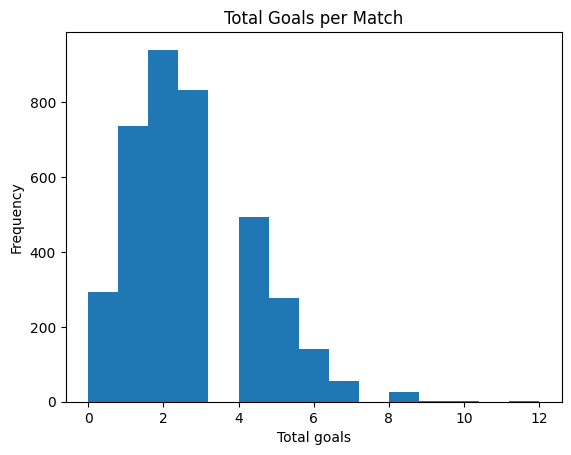

In [16]:
df["total_goals"].plot(kind="hist", bins=15)
plt.title("Total Goals per Match")
plt.xlabel("Total goals")
plt.ylabel("Frequency")
plt.show()


In [11]:
df["season"].value_counts().head(20)


season
1516    380
1617    380
1718    380
1819    380
1920    380
2021    380
2122    380
2223    380
2324    380
2425    380
Name: count, dtype: int64

In [12]:
season_goals = df.groupby("season")[["FTHG", "FTAG"]].mean()
season_goals


,FTHG,FTAG
season,,
1516,1.618421,1.126316
1617,1.663158,1.278947
1718,1.547368,1.147368
1819,1.452632,1.134211
1920,1.436842,1.042105
2021,1.368421,1.139474
2122,1.421053,1.081579
2223,1.455263,1.057895
2324,1.484211,1.160526


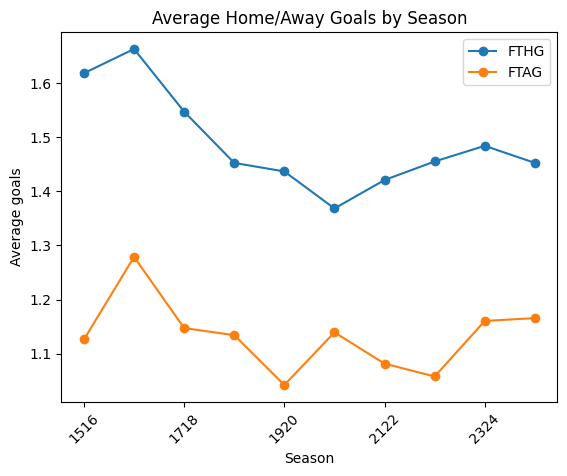

In [15]:
season_goals.plot(kind="line", marker="o")
plt.title("Average Home/Away Goals by Season")
plt.xlabel("Season")
plt.ylabel("Average goals")
plt.xticks(rotation=45)
plt.show()
